# Semana 3 - Backpropagation y Funciones de Activación

## Objetivo
Implementar una red neuronal básica entrenable para el problema XOR y comparar el comportamiento de dos funciones de activación en la **capa oculta**: **sigmoid** y **ReLU**.

## Qué vas a aprender en este notebook
- Qué hace una red neuronal en el paso **forward**
- Cómo se calcula el **error (loss)**
- Cómo funciona **backpropagation**
- Cómo cambian los resultados al variar la activación
- Cómo interpretar una **métrica** y una **gráfica de entrenamiento**

## 1. Idea general de la actividad

La red neuronal sigue este ciclo:

1. **Recibe entradas** (`X`)
2. **Calcula una predicción**
3. **Compara** la predicción con el valor real (`y`)
4. **Mide el error**
5. **Ajusta pesos y sesgos**
6. **Repite** muchas veces

Ese ciclo es el proceso de aprendizaje.

En esta actividad mantendremos igual:
- el dataset
- la arquitectura
- la tasa de aprendizaje
- el número de épocas
- los pesos iniciales

Y solo cambiamos **la función de activación de la capa oculta** para que la comparación sea válida.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla para reproducibilidad
np.random.seed(42)

## 2. Dataset: problema XOR

Usaremos el problema XOR porque es un ejemplo clásico en redes neuronales.

Tabla XOR:

| x1 | x2 | y |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Este problema es útil porque **no se resuelve bien con una sola transformación lineal**.
Por eso una red con capa oculta sí resulta interesante.

In [2]:
# Datos de entrenamiento
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

print("Entradas X:")
print(X)
print("\nSalidas esperadas y:")
print(y)

Entradas X:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Salidas esperadas y:
[[0.]
 [1.]
 [1.]
 [0.]]


## 3. Funciones de activación

En esta actividad compararemos:
- **Sigmoid**
- **ReLU**

La salida final de la red será **sigmoid**, porque el problema XOR tiene salida binaria (0 o 1).

### ¿Por qué solo cambiaremos la activación oculta?
Porque así la comparación es más clara:
- la arquitectura sigue igual
- la salida sigue siendo binaria
- solo analizamos cómo cambia el aprendizaje en la parte interna de la red

In [3]:
# Función sigmoid y derivada
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative_from_output(a):
    # Si a = sigmoid(z), entonces la derivada es a * (1 - a)
    return a * (1 - a)

# Función ReLU y derivada
def relu(x):
    return np.maximum(0, x)

def relu_derivative_from_z(z):
    return (z > 0).astype(float)

## 4. Métricas auxiliares

Usaremos:

- **MSE (Mean Squared Error)** como pérdida
- **Accuracy** como métrica de desempeño

### MSE
Mide qué tan lejos está la predicción del valor real.

### Accuracy
Convierte las salidas en 0 o 1 usando un umbral de 0.5 y calcula cuántas quedaron correctas.

In [4]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def accuracy(y_true, y_pred):
    y_pred_binary = (y_pred >= 0.5).astype(int)
    return np.mean(y_true == y_pred_binary)

## 5. Clase de la red neuronal

Esta red tendrá:

- **2 entradas**
- **1 capa oculta** con 4 neuronas
- **1 salida**

Arquitectura: **[2, 4, 1]**

### Qué hace cada método
- `forward`: calcula la salida
- `backward`: ajusta pesos y sesgos con backpropagation
- `predict`: devuelve predicciones finales

In [5]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size,
                 hidden_activation, hidden_activation_name,
                 W1_init, b1_init, W2_init, b2_init):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.hidden_activation = hidden_activation
        self.hidden_activation_name = hidden_activation_name

        # Usamos los mismos pesos iniciales para ambas redes
        # así la comparación entre activaciones es más justa
        self.W1 = W1_init.copy()
        self.b1 = b1_init.copy()
        self.W2 = W2_init.copy()
        self.b2 = b2_init.copy()

        self.loss_history = []
        self.acc_history = []

    def hidden_activation_derivative(self, z, a):
        if self.hidden_activation_name == "sigmoid":
            return sigmoid_derivative_from_output(a)
        elif self.hidden_activation_name == "relu":
            return relu_derivative_from_z(z)
        else:
            raise ValueError("Activación oculta no soportada")

    def forward(self, X):
        # Capa oculta
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.hidden_activation(self.z1)

        # Capa de salida (usamos sigmoid para salida binaria)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)

        return self.a2

    def backward(self, X, y, y_pred, learning_rate):
        m = X.shape[0]  # número de muestras

        # Error en la salida
        # Para MSE + salida sigmoid:
        d_a2 = (y_pred - y)
        d_z2 = d_a2 * sigmoid_derivative_from_output(y_pred)

        # Gradientes de W2 y b2
        d_W2 = np.dot(self.a1.T, d_z2) / m
        d_b2 = np.sum(d_z2, axis=0, keepdims=True) / m

        # Error propagado a la capa oculta
        d_a1 = np.dot(d_z2, self.W2.T)
        d_z1 = d_a1 * self.hidden_activation_derivative(self.z1, self.a1)

        # Gradientes de W1 y b1
        d_W1 = np.dot(X.T, d_z1) / m
        d_b1 = np.sum(d_z1, axis=0, keepdims=True) / m

        # Actualización de parámetros
        self.W2 -= learning_rate * d_W2
        self.b2 -= learning_rate * d_b2
        self.W1 -= learning_rate * d_W1
        self.b1 -= learning_rate * d_b1

    def train(self, X, y, epochs=5000, learning_rate=0.1):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = mse(y, y_pred)
            acc = accuracy(y, y_pred)

            self.backward(X, y, y_pred, learning_rate)

            self.loss_history.append(loss)
            self.acc_history.append(acc)

    def predict(self, X):
        return self.forward(X)

## 6. Configuración del experimento

Vamos a conservar esta configuración:
- arquitectura: **2-4-1**
- épocas: **10000**
- learning rate: **0.1**
- dataset: **XOR**
- pesos iniciales: iguales para ambas redes

Solo cambia la activación oculta:
- red 1: **sigmoid**
- red 2: **ReLU**

In [6]:
# Configuración base
input_size = 2
hidden_size = 4
output_size = 1
epochs = 10000
learning_rate = 0.1

# Mismos pesos iniciales para ambas redes
W1_init = np.random.randn(input_size, hidden_size) * 0.5
b1_init = np.zeros((1, hidden_size))

W2_init = np.random.randn(hidden_size, output_size) * 0.5
b2_init = np.zeros((1, output_size))

## 7. Entrenamiento con activación oculta sigmoid

In [7]:
nn_sigmoid = NeuralNetwork(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    hidden_activation=sigmoid,
    hidden_activation_name="sigmoid",
    W1_init=W1_init,
    b1_init=b1_init,
    W2_init=W2_init,
    b2_init=b2_init
)

nn_sigmoid.train(X, y, epochs=epochs, learning_rate=learning_rate)

## 8. Entrenamiento con activación oculta ReLU

In [8]:
nn_relu = NeuralNetwork(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    hidden_activation=relu,
    hidden_activation_name="relu",
    W1_init=W1_init,
    b1_init=b1_init,
    W2_init=W2_init,
    b2_init=b2_init
)

nn_relu.train(X, y, epochs=epochs, learning_rate=learning_rate)

## 9. Comparación del entrenamiento

Aquí observamos cómo evoluciona el **loss** durante las épocas.

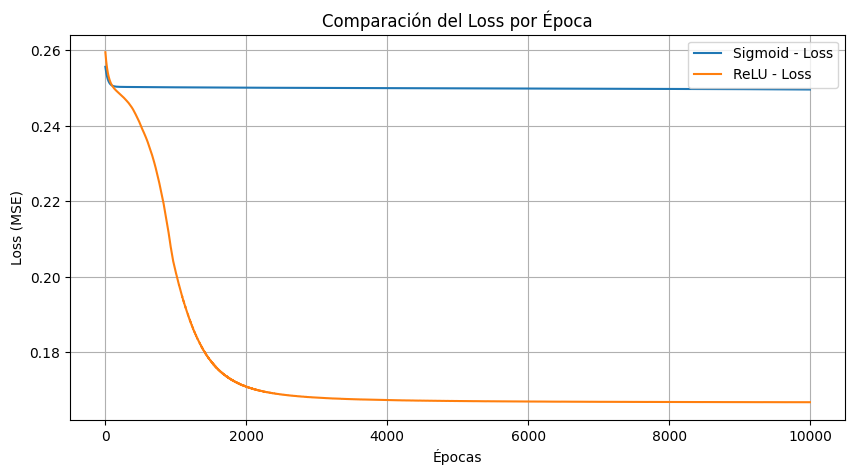

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(nn_sigmoid.loss_history, label="Sigmoid - Loss")
plt.plot(nn_relu.loss_history, label="ReLU - Loss")
plt.title("Comparación del Loss por Época")
plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

## 10. Predicciones finales y métricas

Ahora revisamos:
- las salidas finales de cada red
- las predicciones binarias
- el loss final


In [13]:
# Predicciones finales
pred_sigmoid = nn_sigmoid.predict(X)
pred_relu = nn_relu.predict(X)

pred_sigmoid_binary = (pred_sigmoid >= 0.5).astype(int)
pred_relu_binary = (pred_relu >= 0.5).astype(int)

print("=== RESULTADOS CON ACTIVACIÓN OCULTA SIGMOID ===")
print("Salidas continuas:")
print(pred_sigmoid)
print("Predicciones binarias:")
print(pred_sigmoid_binary)
print("Loss final:", nn_sigmoid.loss_history[-1])
print("Acierto final:", accuracy(y, pred_sigmoid))

print("\n=== RESULTADOS CON ACTIVACIÓN OCULTA ReLU ===")
print("Salidas continuas:")
print(pred_relu)
print("Predicciones binarias:")
print(pred_relu_binary)
print("Loss final:", nn_relu.loss_history[-1])
print("Acierto final:", accuracy(y, pred_relu))

=== RESULTADOS CON ACTIVACIÓN OCULTA SIGMOID ===
Salidas continuas:
[[0.49374877]
 [0.50313573]
 [0.49962923]
 [0.50754351]]
Predicciones binarias:
[[0]
 [1]
 [0]
 [1]]
Loss final: 0.24965843867996967
Acierto final: 0.5

=== RESULTADOS CON ACTIVACIÓN OCULTA ReLU ===
Salidas continuas:
[[0.66574168]
 [0.66574168]
 [0.66574168]
 [0.02472213]]
Predicciones binarias:
[[1]
 [1]
 [1]
 [0]]
Loss final: 0.16682020892676921
Acierto final: 0.75


## 11. Comparación directa en tabla

In [14]:
import pandas as pd

results = pd.DataFrame({
    "Modelo": ["Sigmoid", "ReLU"],
    "Loss final": [nn_sigmoid.loss_history[-1], nn_relu.loss_history[-1]],
    "Acierto final": [accuracy(y, pred_sigmoid), accuracy(y, pred_relu)]
})

results

,Modelo,Loss final,Acierto final
0,Sigmoid,0.249658,0.50
1,ReLU,0.166820,0.75


## 12. Interpretación de resultados

### Cómo leer la gráfica de loss
- Si el loss baja, la red está aprendiendo.
- Si el loss se queda plano, el aprendizaje es bajo.
- Si el loss oscila mucho, puede haber problemas con la tasa de aprendizaje o la activación.

### Cómo leer los aciertos
- Acierto = 1.0 significa que acertó todos los casos de XOR.
- Acierto = 0.5 significa que acertó solo la mitad.
- Mientras más alta sea, mejor desempeño tuvo la red.

## 13. Conclusiones

### Conclusión 1: ¿Qué cambió al variar la activación?
Al cambiar la activación oculta, cambió la forma en que la red transformó la información interna y, por tanto, el comportamiento del entrenamiento.

### Conclusión 2: ¿Cómo se comportó el loss y la métrica?
La comparación del loss y la accuracy permitió observar cuál activación facilitó un aprendizaje más estable o más rápido en el problema XOR.

### Conclusión 3: Dificultades o hallazgos
Se dificulta entender que la red no “adivina”, sino que ajusta pesos y sesgos poco a poco a partir del error. También fue importante mantener constante la configuración base para que la comparación entre activaciones fuera válida.